# Section 4.2/4.3 Portfolio implementation and backtesting

## 0. Packages and variables

In [1]:
import _paths  # noqa: F401
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import backtest as bt
import plotting as pltg
from config import CONFIG, DT_DAILY, DT_MONTHLY
from paths import DATA, FIGURES, relative_path
from plotting import use_paper_style as ups
from simulate import MeanRevertingSDDModel as SDDModel

%load_ext autoreload
%autoreload 2

In [2]:
(width, height) = ups(usetex=True)

In [3]:
# Import config params
bt_cfg = CONFIG["backtest_config"]

START_DATE, WARMUP_END_DATE = bt_cfg["warmup_dates"]
BACKTEST_START_DATE, END_DATE = bt_cfg["backtest_dates"]
W0 = bt_cfg["W0"]
TC = bt_cfg["TC"]
TARGET_ACTIVE_RISK = bt_cfg["tgt_active_risk"]
H_PHI = bt_cfg["trend_halflife"]
M_mr = bt_cfg["mr_M"]
M_trend = bt_cfg["trend_M"]

# 1. Real data

## 1.1. Load Data

In [4]:
monthly_rets = pd.read_csv(
    f"{DATA}/processed/rets_monthly_1977.csv", index_col=0, parse_dates=True
)
monthly_caps = pd.read_csv(
    f"{DATA}/processed/caps_monthly_1977.csv", index_col=0, parse_dates=True
)
monthly_mkt_wgts = pd.read_csv(
    f"{DATA}/processed/mkt_wgts_monthly_1977.csv", index_col=0, parse_dates=True
)
monthly_eql_wgts = pd.read_csv(
    f"{DATA}/processed/eql_wgts_monthly_1977.csv", index_col=0, parse_dates=True
)

signals = pd.read_csv(
    f"{DATA}/processed/signals_1977.csv", index_col=0, parse_dates=True
)

signals_clean = pd.read_csv(
    f"{DATA}/processed/signals_clean_1977.csv", index_col=0, parse_dates=True
)

In [5]:
diversity = signals["diversity"]
dispersion = signals["dispersion"]

diversity_monthly = diversity.resample("ME").last()
diversity_qv_monthly = diversity.diff().pow(2).resample("ME").sum() / DT_MONTHLY
dispersion_monthly = dispersion.resample("ME").sum() * DT_DAILY / DT_MONTHLY

diversity_clean = signals_clean["diversity"]
dispersion_clean = signals_clean["dispersion"]

diversity_clean_monthly = diversity_clean.resample("ME").last()
diversity_qv_clean_monthly = (
    diversity_clean.diff().pow(2).resample("ME").sum() / DT_MONTHLY
)
dispersion_clean_monthly = dispersion_clean.resample("ME").sum() * DT_DAILY / DT_MONTHLY

In [6]:
ff5_factors = pd.read_csv(
    f"{DATA}/external/FF5_1977.csv", index_col=0, parse_dates=True
)
ff5_factors = ff5_factors.loc[BACKTEST_START_DATE:END_DATE]
rf_ret_monthly = ff5_factors["RF"].copy()

## 1.2. Backtest $\lambda$-tilt portfolios

In [7]:
# compute mean reversion and trending signals
mr_sig = bt.LbdaMeanReversion(
    diversity=diversity_clean_monthly,
    dispersion=dispersion_clean_monthly,
    diversity_qv=diversity_qv_clean_monthly,
    dt=DT_MONTHLY,
    warmup_dates=(START_DATE, WARMUP_END_DATE),
    horizon=M_mr,
)
mr_sig.calibrate_signal()

print("Mean reversion signal parameters:")
print("------------------------")
print("\n".join(f"{k}: {v.round(3)}" for k, v in mr_sig.params.items()))

trend_sig = bt.LbdaTrend(
    diversity=diversity_clean,
    dispersion=dispersion_clean_monthly,
    dt=DT_MONTHLY,
    warmup_dates=(START_DATE, WARMUP_END_DATE),
    horizon=M_trend,
    h_phi=H_PHI,
)
trend_sig.calibrate_signal()

print("\nTrending signal parameters:")
print("------------------------")
print("\n".join(f"{k}: {v.round(10)}" for k, v in trend_sig.params.items()))

signal_dict = {"mr": mr_sig, "trend": trend_sig}

Mean reversion signal parameters:
------------------------
kappa_phi: 0.432
phi_bar: -6.932
nu_phi: 0.299
kappa_delta: 5.524
nu_delta: 0.991
delta_bar: 0.018
rho: -0.295

Trending signal parameters:
------------------------
omega: 6.36e-07
alpha_v: 0.1409921142
beta_v: 0.7863294833
v_bar: 8.7516e-06


In [8]:
# initializing lambda portfolio
lbda_ports = bt.LbdaPortfolio(
    rets=monthly_rets,
    mkt_caps=monthly_caps,
    mkt_wgts=monthly_mkt_wgts,
    eql_wgts=monthly_eql_wgts,
    signal_dict=signal_dict,
    div_qv_rate=diversity_qv_monthly,
    rf_ret=rf_ret_monthly,
    W0=W0,
    tc=TC,
    target_active_risk=TARGET_ACTIVE_RISK,
    warmup_dates=(START_DATE, WARMUP_END_DATE),
    backtest_dates=(BACKTEST_START_DATE, END_DATE),
    dt=DT_MONTHLY,
)

In [9]:
# backtesting portfolios
lbda_ports.run_backtest(save_results=True)

Starting backtest...
Building lbda portfolios...
Lbda_1: 1.049.
--- Signal: mr ---
[mr] Calibrated gamma: 19.91
Lbda_1: 1.168.
[mr] Calibrated Lbda_2: 0.537
--- Signal: trend ---
[trend] Calibrated gamma: 30.11
Lbda_1: 0.528.
[trend] Calibrated Lbda_2: 0.094
Lbda portfolios built.
Backtest completed.
Saved summary results to ./results/summary_stats.csv


Saved figure to ./figures/portfolio_costs.pdf


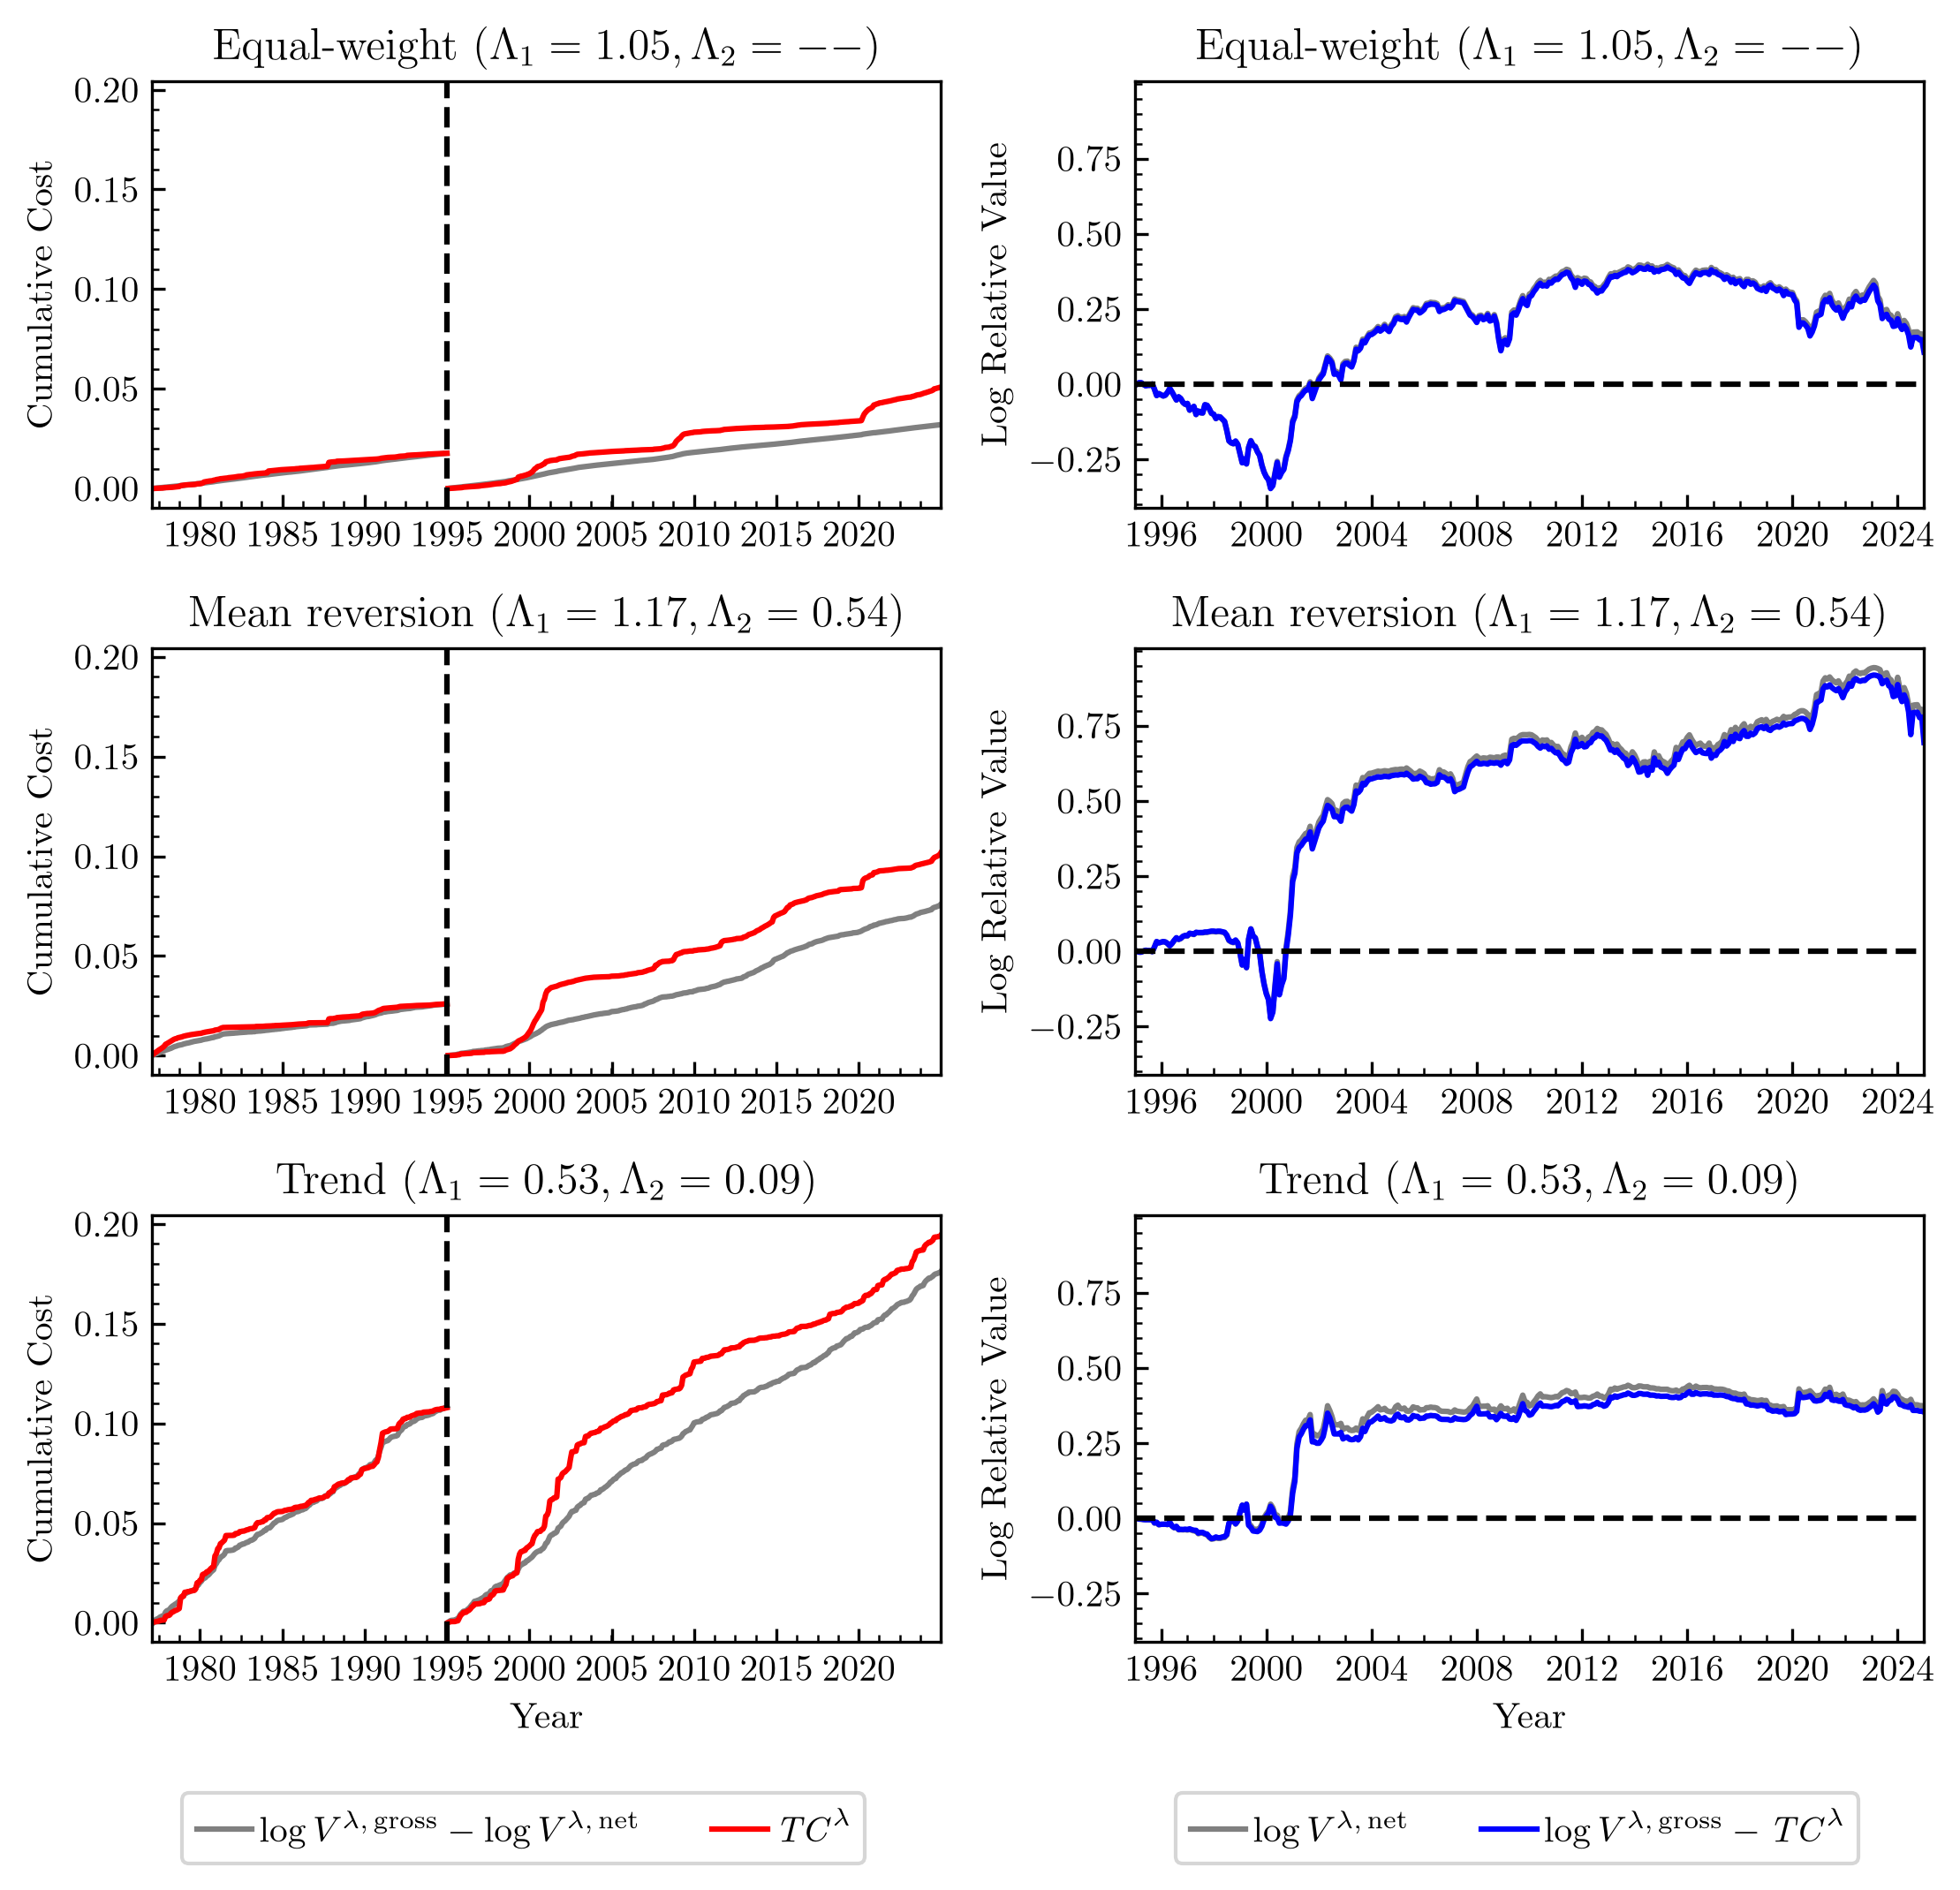

In [10]:
# plotting portfolio active costs (difference in gross vs net log relative value) vs calibrated transaction cost penalties
pltg.plot_portfolio_costs(
    lbda_ports, 
    figsize=(width * 1.5, height * 2.25), 
    tight_layout=True, sharey="col",
    save_fig=True,
)

Saved figure to ./figures/portfolio_performance.pdf


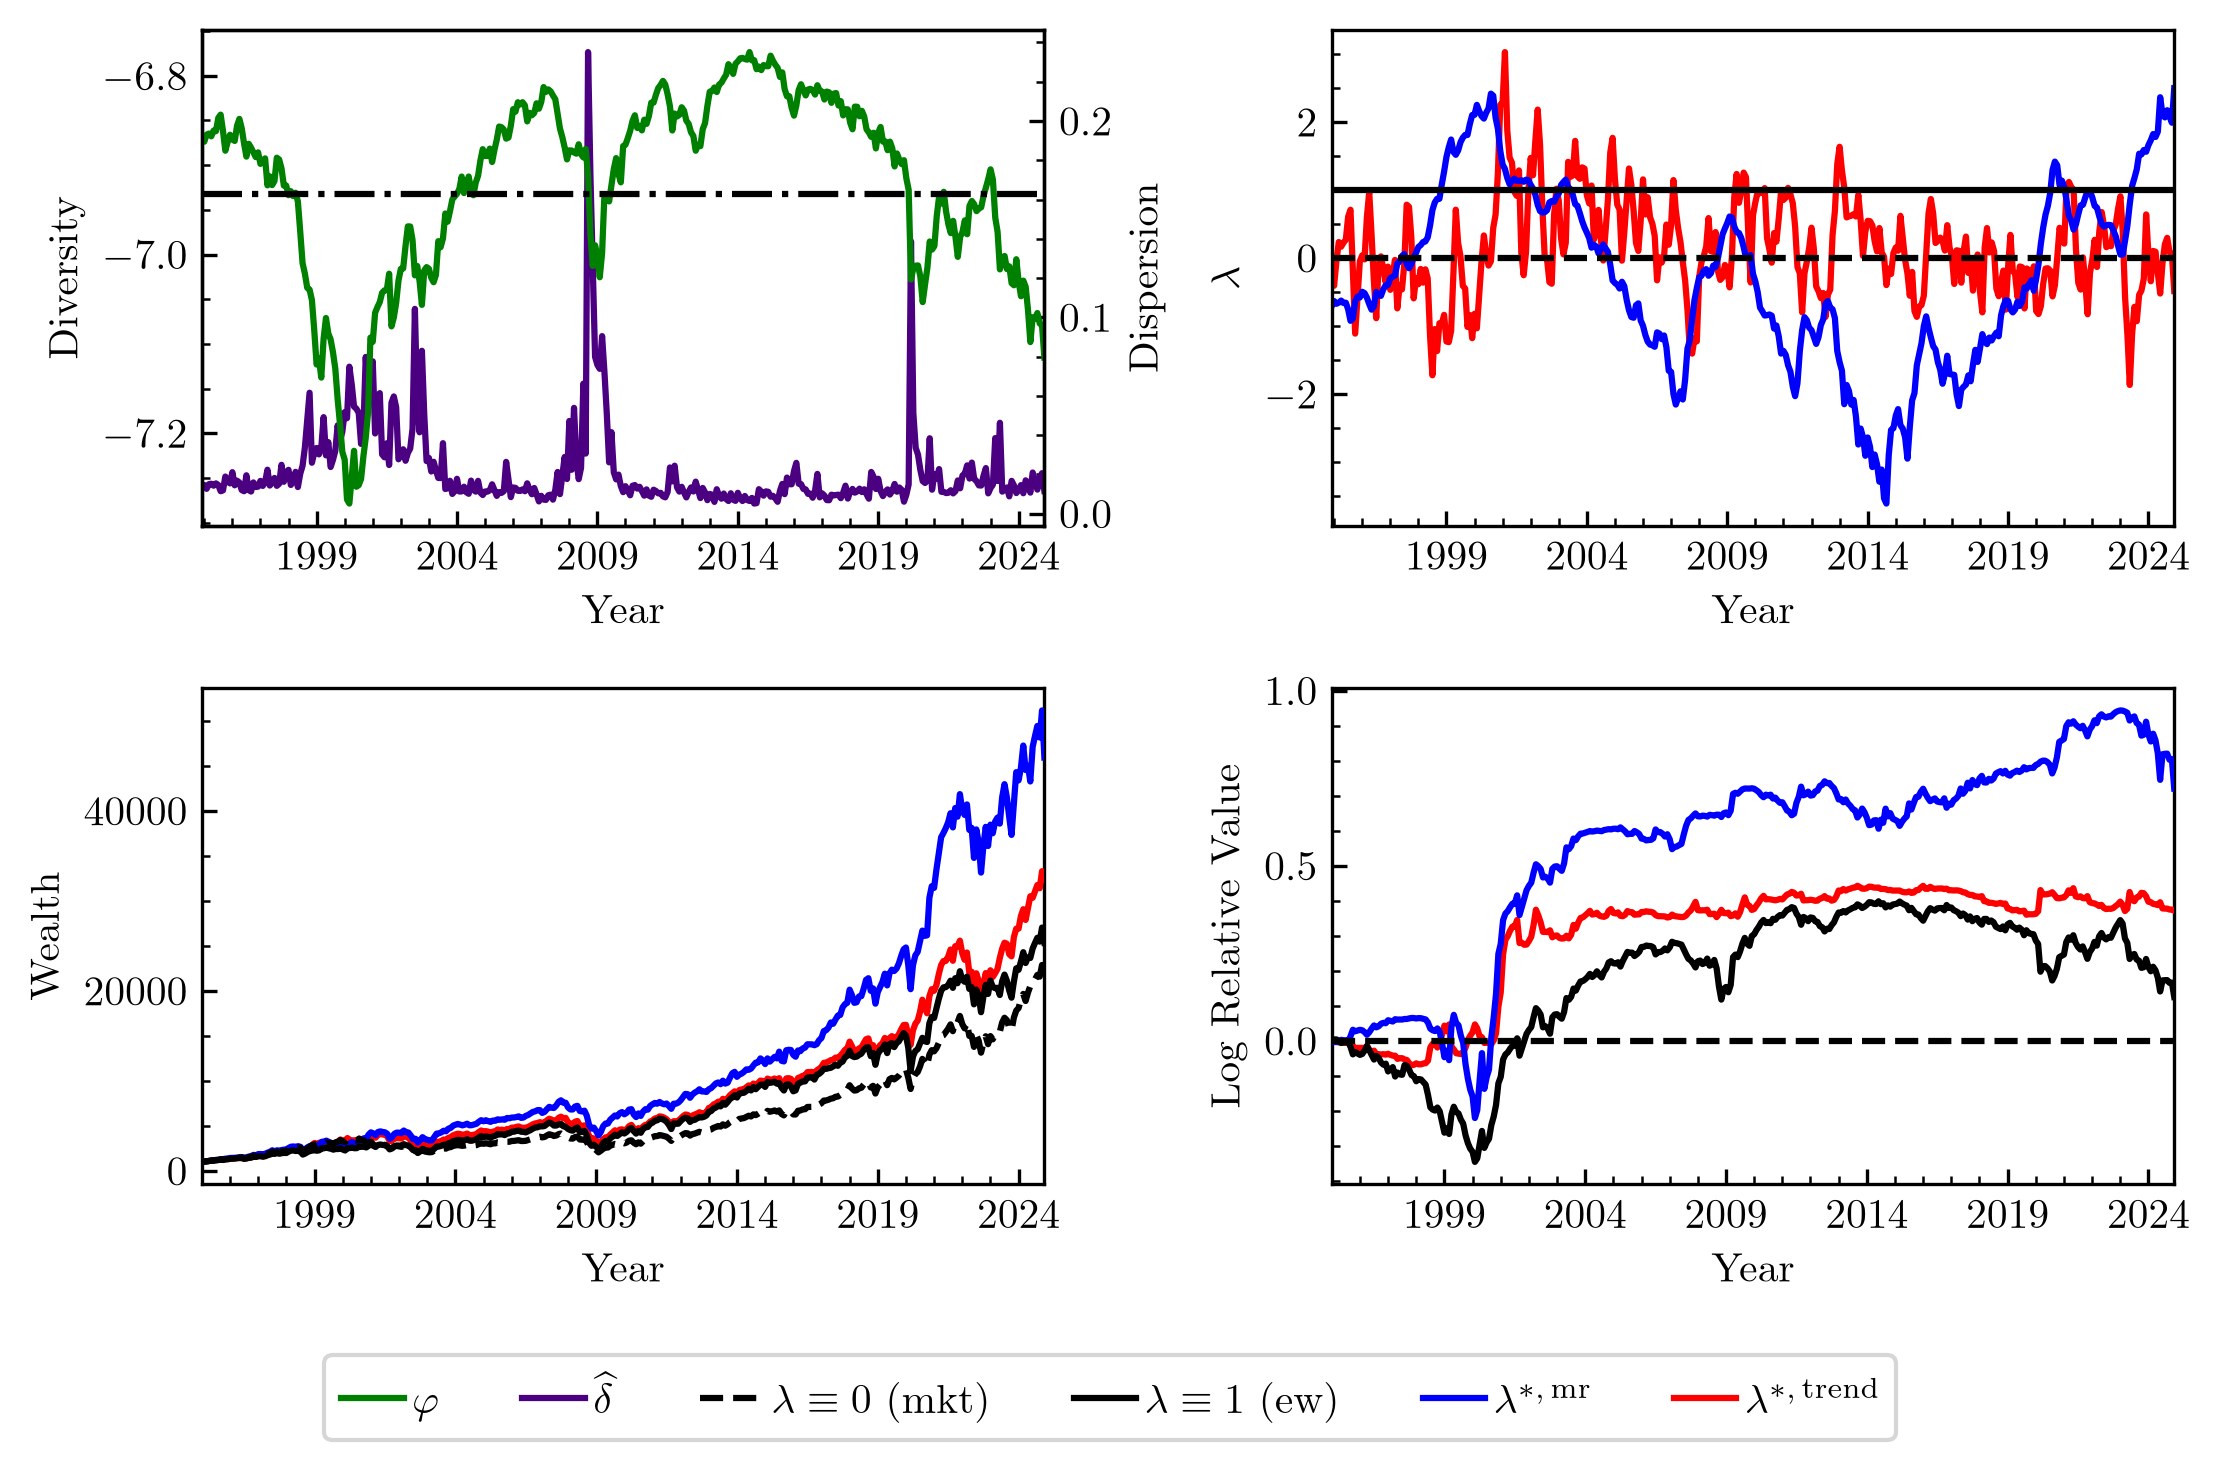

In [11]:
# plotting portfolio performance
pltg.plot_portfolio_performance(
    lbda_ports,
    diversity_monthly,
    dispersion_monthly,
    figsize=(1.5 * width, 1.5 * height),
    tight_layout=True,
    save_fig=True
)

In [12]:
# backtest summary statistics
lbda_ports.summary_stats.round(2).T

,total_ret,mean_ret,volatility,sharpe_ratio,gross_exposure,turnover,max_drawdown,recovery_time,gross_sharpe_ratio,information_ratio
mkt,21.34,0.12,0.15,0.61,1.00,0.01,0.50,73.0,0.61,NaN
ew,24.33,0.12,0.17,0.58,1.00,0.07,0.56,44.0,0.59,0.13
mr_0,32.10,0.13,0.17,0.65,1.64,0.41,0.51,52.0,0.69,0.21
mr,44.92,0.14,0.16,0.72,1.45,0.15,0.50,50.0,0.74,0.35
mr_bar,32.46,0.13,0.16,0.68,1.00,0.05,0.50,39.0,0.68,0.34
trend_0,32.49,0.13,0.16,0.69,1.17,0.59,0.50,41.0,0.76,0.26
trend,31.41,0.13,0.15,0.69,1.11,0.34,0.51,41.0,0.73,0.29
trend_bar,26.43,0.12,0.16,0.65,1.00,0.15,0.51,41.0,0.66,0.29


In [13]:
# Calibrated model parameters
params = {
    "gamma": lbda_ports.gamma_dict,
    "Lbda_1": lbda_ports.Lbda_1_dict,
    "Lbda_2": lbda_ports.Lbda_2_dict,
}
params = pd.DataFrame(params)
params

,gamma,Lbda_1,Lbda_2
mr,19.910605,1.168143,0.536953
trend,30.109591,0.528102,0.093906
ew,NaN,1.049231,NaN


## 1.3. Sensitivity Analysis

In [14]:
# Information ratio sensitivity matrix in Lbda_1 and Lbda_2
Lbda_1_idxs = np.arange(-4, 10, 2)
Lbda_2_idxs = np.arange(-4, 12, 2)
Lbda_1_grid = params.loc[["mr", "trend"], "Lbda_1"].values * 2.0 ** Lbda_1_idxs.reshape(
    -1, 1
)
Lbda_2_grid = params.loc[["mr", "trend"], "Lbda_2"].values * 2.0 ** Lbda_2_idxs.reshape(
    -1, 1
)
gamma_dict = params["gamma"].to_dict()

Lbda_ir_arrays = bt.sensitivity_analysis(
    signal_dict=signal_dict,
    Lbda_1_grid=Lbda_1_grid,
    Lbda_2_grid=Lbda_2_grid,
    gamma_dict=gamma_dict,
    rets=monthly_rets,
    mkt_caps=monthly_caps,
    mkt_wgts=monthly_mkt_wgts,
    eql_wgts=monthly_eql_wgts,
    div_qv_rate=diversity_qv_monthly,
    rf_ret=rf_ret_monthly,
    W0=W0,
    tc=TC,
    target_active_risk=TARGET_ACTIVE_RISK,
    warmup_dates=(START_DATE, WARMUP_END_DATE),
    backtest_dates=(BACKTEST_START_DATE, END_DATE),
    dt=DT_MONTHLY,
)

Running sensitivity analysis (56 / 56)
Lbda_1_dict={'mr': np.float64(299.0447), 'trend': np.float64(135.1941)},
Lbda_2_dict={'mr': np.float64(549.84), 'trend': np.float64(96.16)}
Starting backtest...
Building lbda portfolios...
Lbda_1: 1.049.
--- Signal: mr ---
--- Signal: trend ---
Lbda portfolios built.
Backtest completed.


Saved figure to ./figures/ir_surface.pdf


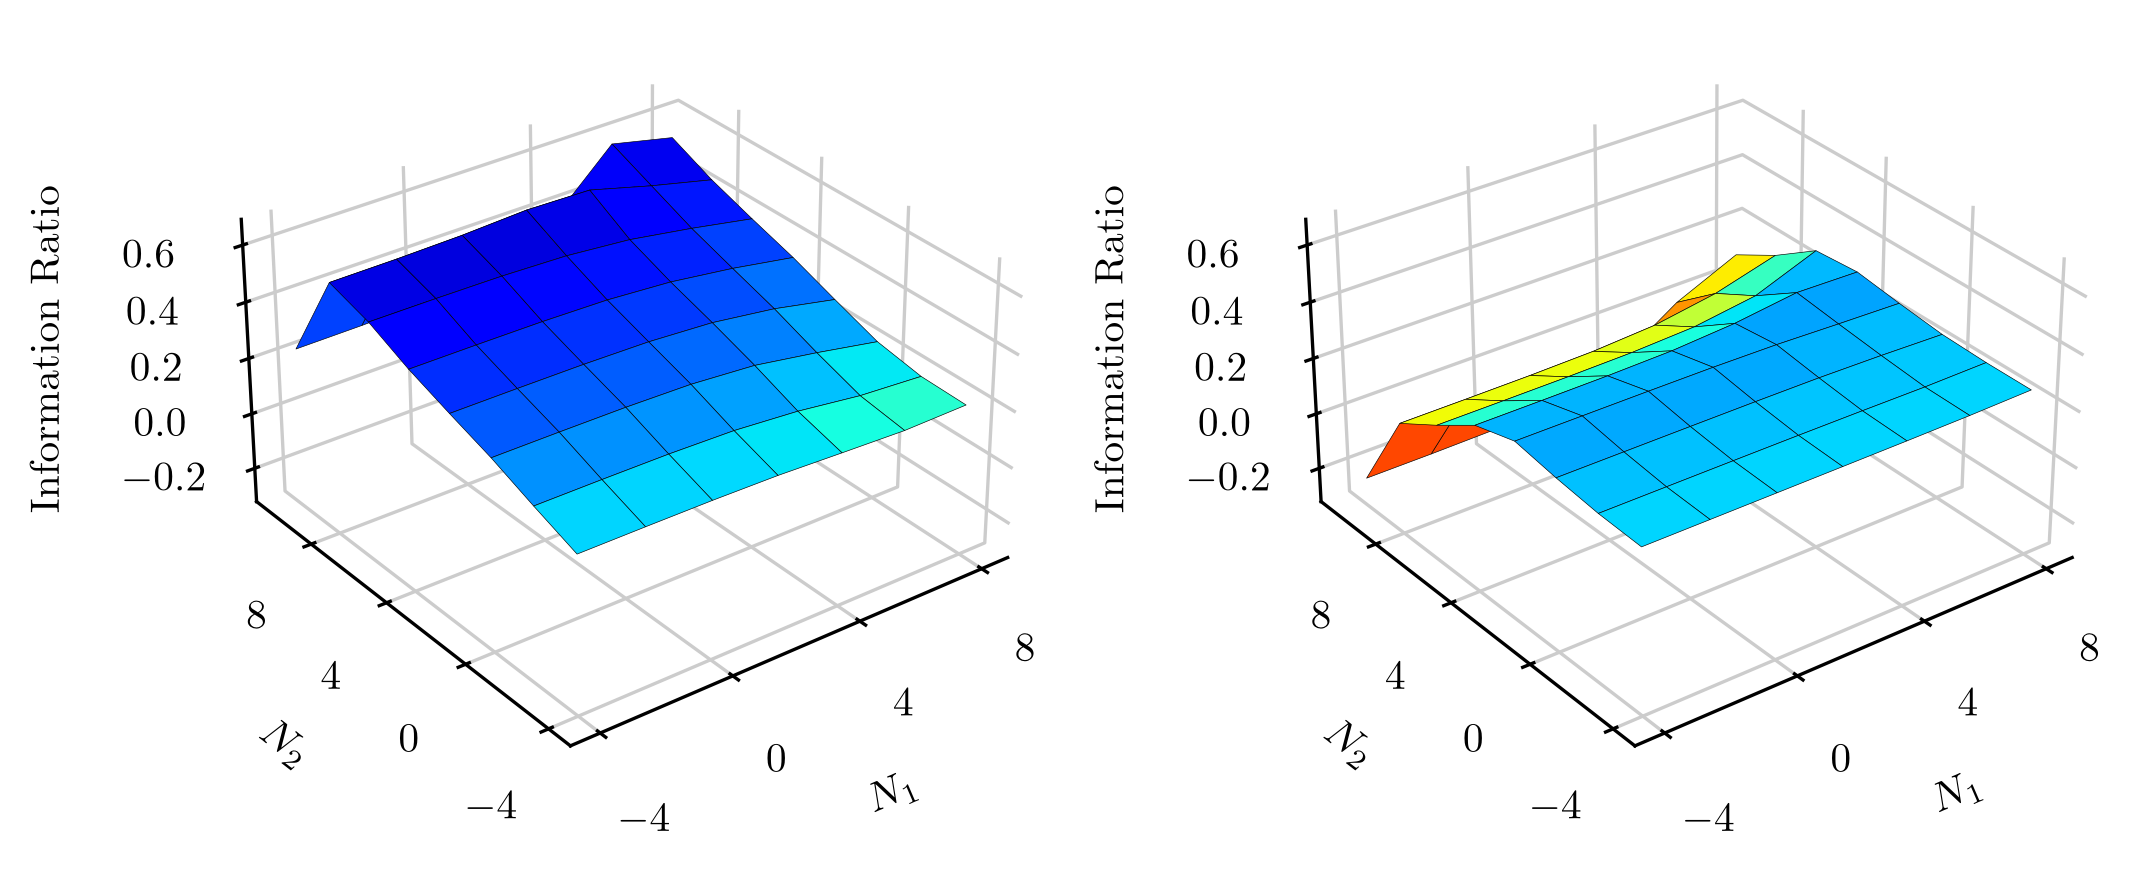

In [15]:
# Plotting information ratio sensitivity surface
pltg.plot_ir_surf(
    Lbda_1_idxs,
    Lbda_2_idxs,
    Lbda_ir_arrays,
    figsize=(2 * width, height),
    subplot_kw={"projection": "3d"},
    tight_layout=True,
    save_fig=True
)

## 1.4. Fama-French Regression

In [16]:
# Compute net excess returns
net_excess_ret_df = (
    lbda_ports.net_wealth_df.pct_change()
    .dropna()
    .subtract(ff5_factors["RF"].iloc[1:], axis=0)
)

# set market factor to be SP500 return, not FF market return
X = ff5_factors.copy().iloc[1:]
X.drop(columns=["Mkt-RF", "RF"], inplace=True)
X.insert(0, "SP500-RF", net_excess_ret_df["mkt"])

In [26]:
print("Fama-French 3-Factor Regression Results:")
print("===============================")
for label in ["mr", "trend", "ew"]:
    print(f"Regression for {label}:")
    _ = bt.ff_regression(
        X=X[["SP500-RF", "SMB", "HML"]],
        y=net_excess_ret_df[label],
        save_results=True,
    )
    print("\n")

Fama-French 3-Factor Regression Results:
Regression for mr:
 R-squared: 0.8292
 Annualized alpha: 0.0247
           coef   tstat
SP500-RF  0.981  40.832
SMB      -0.012  -0.377
HML       0.254   8.152
alpha     0.002   1.943
Saved regression results to ./results/ff_regression/ff3_mr_results.csv


Regression for trend:
 R-squared: 0.9169
 Annualized alpha: 0.0150
           coef   tstat
SP500-RF  0.970  61.784
SMB       0.051   2.372
HML       0.015   0.724
alpha     0.001   1.811
Saved regression results to ./results/ff_regression/ff3_trend_results.csv


Regression for ew:
 R-squared: 0.9437
 Annualized alpha: -0.0041
           coef   tstat
SP500-RF  1.060  73.682
SMB       0.225  11.348
HML       0.265  14.230
alpha    -0.000  -0.537
Saved regression results to ./results/ff_regression/ff3_ew_results.csv




In [27]:
print("Fama-French 5-Factor Regression Results:")
print("===============================")
for label in ["mr", "trend", "ew"]:
    print(f"Regression for {label}:")
    _ = bt.ff_regression(X=X, y=net_excess_ret_df[label], save_results=True)
    print("\n")

Fama-French 5-Factor Regression Results:
Regression for mr:
 R-squared: 0.8330
 Annualized alpha: 0.0154
           coef   tstat
SP500-RF  1.007  38.882
SMB       0.038   0.989
HML       0.178   4.002
RMW       0.123   2.524
CMA       0.093   1.436
alpha     0.001   1.178
Saved regression results to ./results/ff_regression/ff5_mr_results.csv


Regression for trend:
 R-squared: 0.9178
 Annualized alpha: 0.0126
           coef   tstat
SP500-RF  0.980  57.599
SMB       0.054   2.134
HML      -0.021  -0.722
RMW       0.003   0.099
CMA       0.082   1.937
alpha     0.001   1.473
Saved regression results to ./results/ff_regression/ff5_trend_results.csv


Regression for ew:
 R-squared: 0.9450
 Annualized alpha: -0.0096
           coef   tstat
SP500-RF  1.077  69.475
SMB       0.250  10.896
HML       0.212   7.995
RMW       0.058   1.991
CMA       0.084   2.165
alpha    -0.001  -1.229
Saved regression results to ./results/ff_regression/ff5_ew_results.csv




# 2. Simulated data

In [19]:
sim_cfg = CONFIG["simulation_config"]
N_SAMPLES = sim_cfg["N_SAMPLES"]
SDD_SEED = sim_cfg["SEED"]

## 2.1. Backtest path from Section 4.1

In [20]:
# load SDD mean-reverting model
phi_0 = diversity_monthly.iloc[0]
delta_0 = dispersion_monthly.iloc[0]
N = diversity_monthly.shape[0]

sdd_model = SDDModel.load_model("mr_model.json")

delta_min = sdd_model.config["delta_bar"] * 0.25

sim_diversity, sim_dispersion_clipped = sdd_model.sample(
    N=N, phi_0=phi_0, delta_0=delta_0, n_samples=1, seed=SDD_SEED, delta_min=delta_min
)

sim_diversity.index = sim_diversity.index / 12.0
sim_dispersion_clipped.index = sim_dispersion_clipped.index / 12.0

mle_config = sdd_model.config

In [21]:
# set simulation parameters
Lbda_1_sim = params.loc["mr", "Lbda_1"]
Lbda_2_sim = params.loc["mr", "Lbda_2"]

Calibrated gamma: 16.807
Saved figure to ./figures/sim_portfolio_performance.pdf


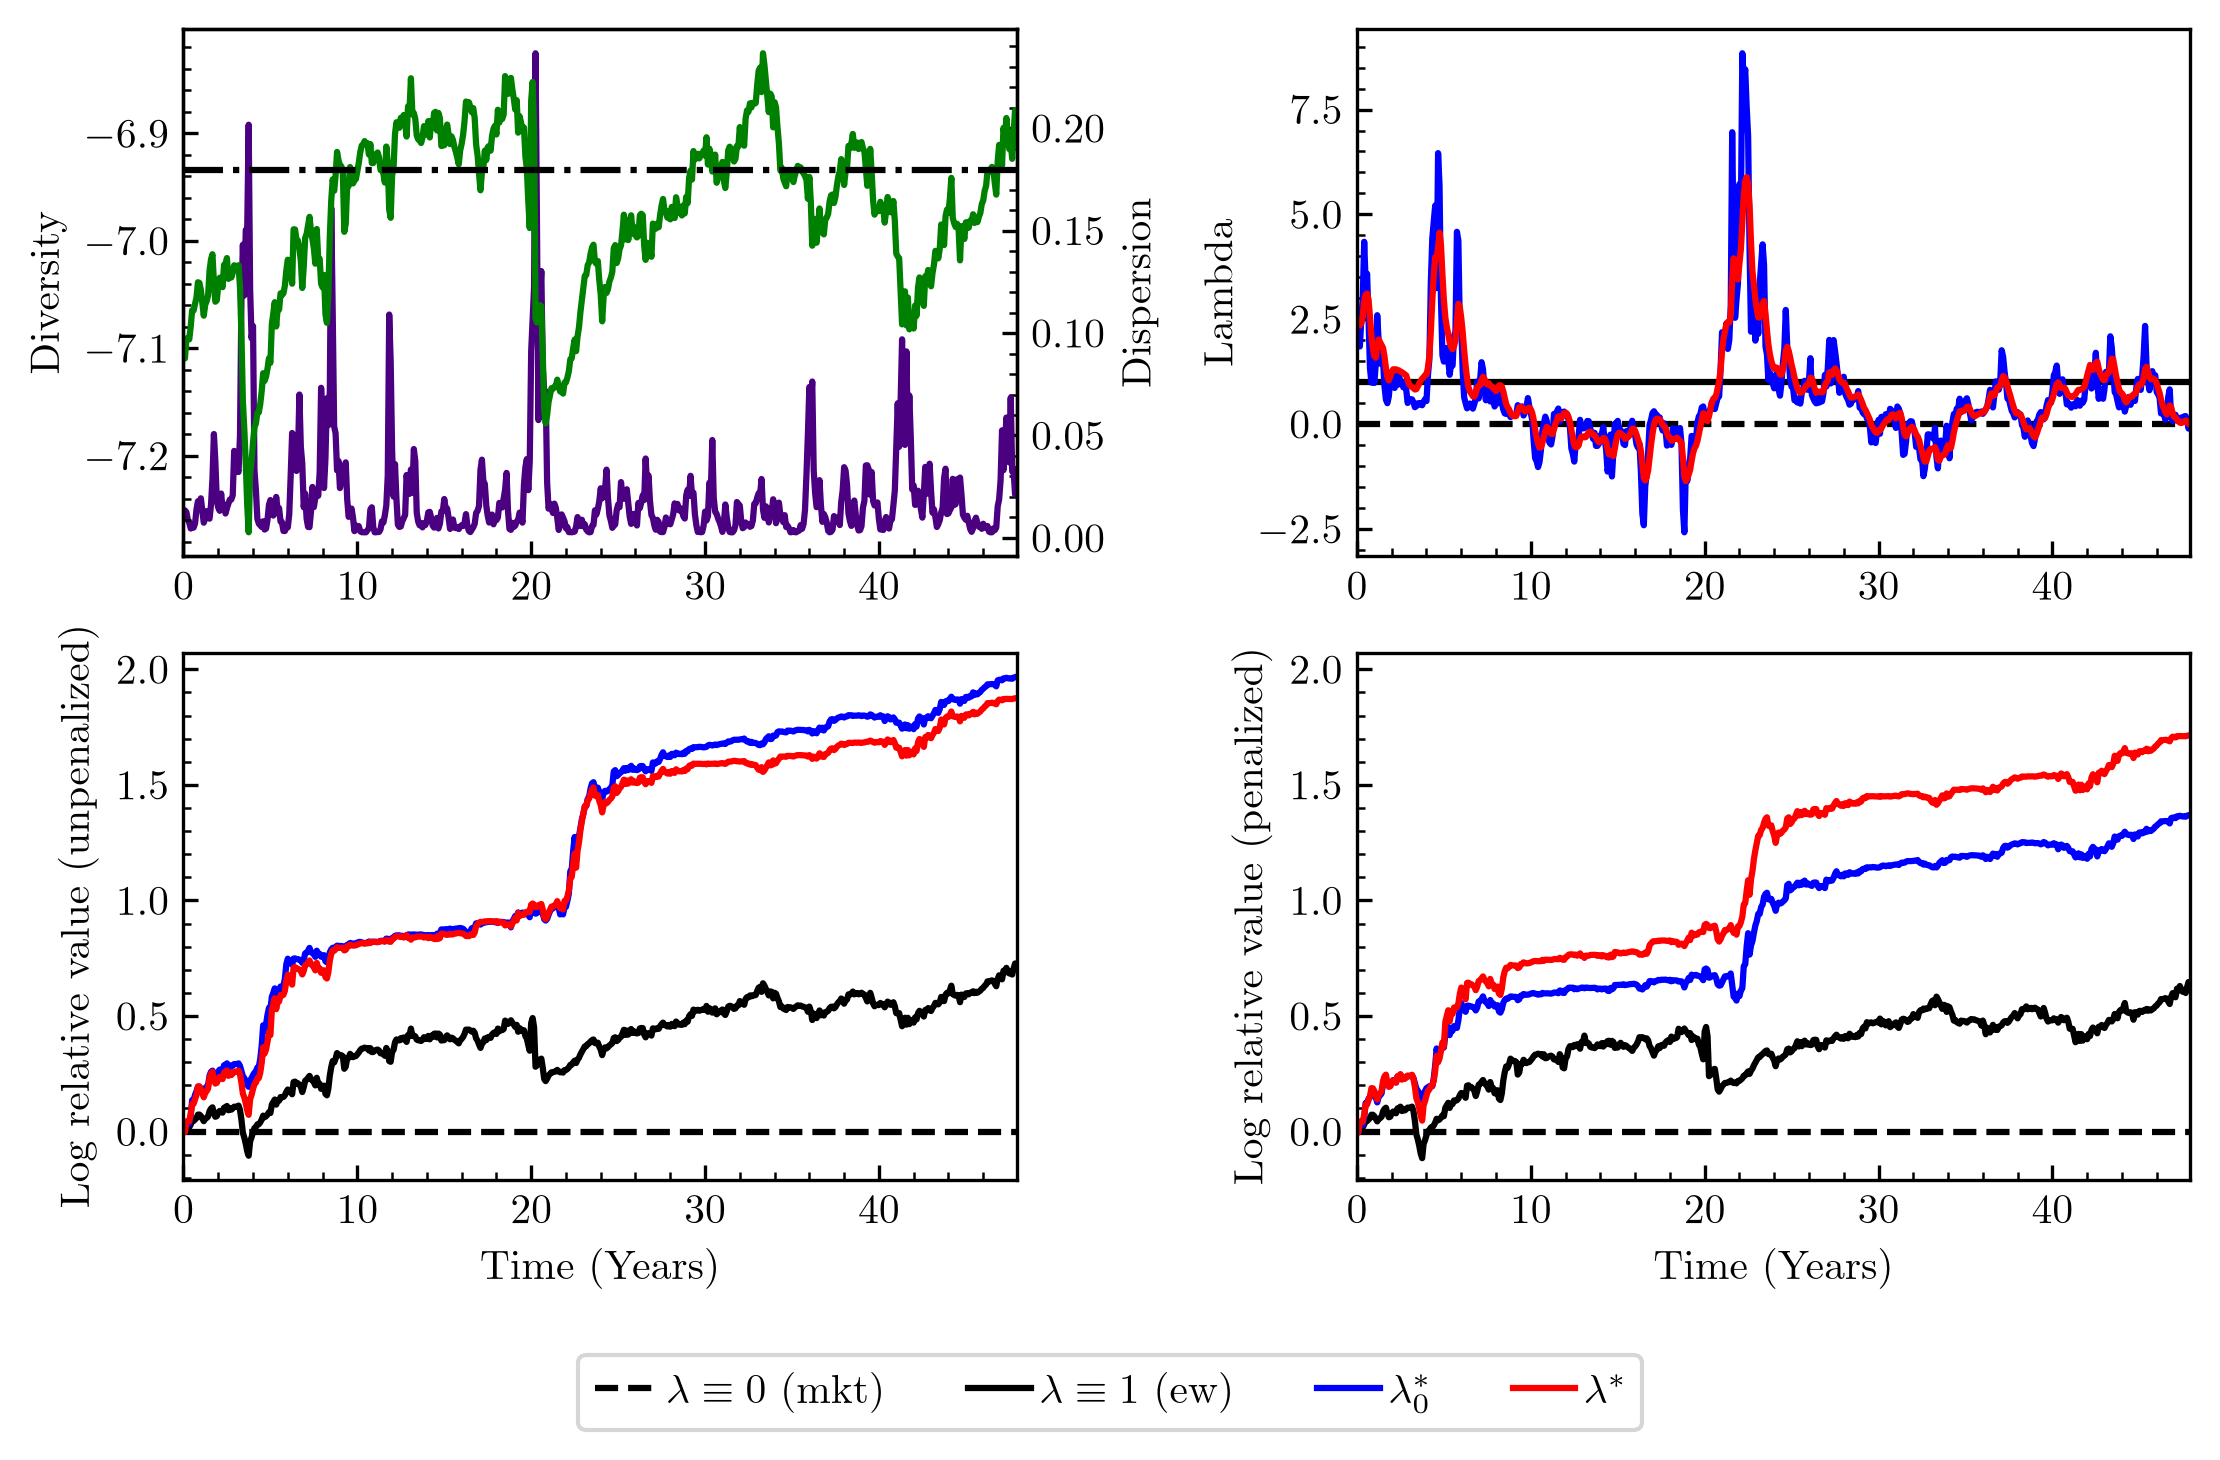

In [22]:
# plotting simulated portfolio performance
pltg.plot_sim_portfolio_performance(
    sdd_model=sdd_model,
    sim_diversity=sim_diversity,
    sim_dispersion=sim_dispersion_clipped,
    Lbda_1_sim=Lbda_1_sim,
    Lbda_2_sim=Lbda_2_sim,
    target_active_risk=TARGET_ACTIVE_RISK,
    figsize=(1.5 * width, 1.5 * height),
    tight_layout=True,
    save_fig=True
)

## 2.2. Large-scale simulation

In [23]:
# simulate N_SAMPLES paths
lbda_bulk_dict, gross_log_V_bulk_dict, net_log_V_bulk_dict, tc_rate_bulk_dict, gamma = (
    sdd_model.backtest(
        target_active_risk=TARGET_ACTIVE_RISK,
        Lbda_1=Lbda_1_sim,
        Lbda_2=Lbda_2_sim,
        n_samples=N_SAMPLES,
        N=N,
        phi_0=phi_0,
        delta_0=delta_0,
        seed=SDD_SEED,
        delta_min=delta_min,
    )
)

Calibrated gamma: 13.245


Saved figure to ./figures/sim_performance_hists.pdf


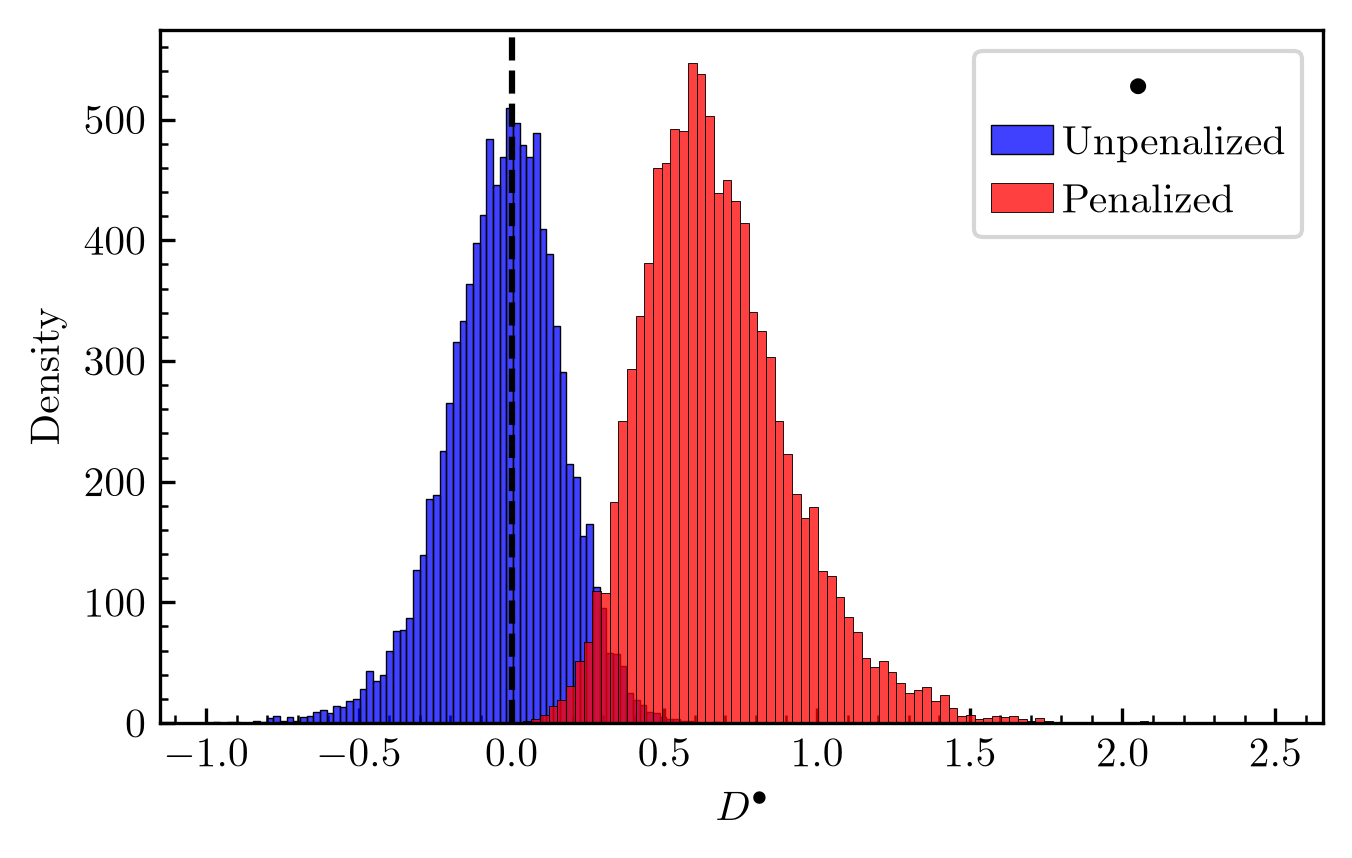

In [24]:
# plotting histograms of differences in terminal log relative values for unpenalized vs penalized strategies
fig, ax = plt.subplots(1, 1)
ax.axvline(0, color="black", linestyle="--")

gross_log_diff = (
    gross_log_V_bulk_dict["lbda"].iloc[-1] - gross_log_V_bulk_dict["lbda_0"].iloc[-1]
)
net_log_diff = (
    net_log_V_bulk_dict["lbda"].iloc[-1] - net_log_V_bulk_dict["lbda_0"].iloc[-1]
)

sns.histplot(gross_log_diff, ax=ax, color="b", label="Unpenalized")

sns.histplot(net_log_diff, ax=ax, color="r", label="Penalized")

ax.set_ylabel("Density")
ax.set_xlabel(
    "$D^\\bullet$"
)

ax.legend(title="$\\bullet$")

save_path = FIGURES / "sim_performance_hists.pdf"
plt.savefig(save_path, format="pdf", dpi=600)
print(f"Saved figure to {relative_path(save_path)}")